In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, binom, geom, lognorm, gamma, expon, weibull_min, pareto
from scipy.stats import skew, kurtosis, shapiro, normaltest

In [2]:
df = pd.read_csv(r"C:\Users\kenne\Downloads\MEG_DATASET\CLEANED_DATASETS_JAN to FEB_2026.csv")
print(df.head())

                                 PAYEE                         PROJECT  \
0                   A M ORETA & CO INC  SUNNY COAST RESIDENTAIL RESORT   
1                   A M ORETA & CO INC  SUNNY COAST RESIDENTAIL RESORT   
2                   A M ORETA & CO INC  SUNNY COAST RESIDENTAIL RESORT   
3  ADVENTURE IMPORT EXPORT CORPORATION              TMN RESI PROJECT 6   
4    ANGELES BUILDERS AND TRADERS INC.           NORTHWIN GLOBAL CITY    

  CHECK NO     AMOUNT                      APV NO                       CV NO  \
0  7519979  294348.21  MBPHI-HO-APVTRD-0000016048  MBPHI-HO-PAYVCH-0000021193   
1  7520060  139218.75  MBPHI-HO-APVTRD-0000016214  MBPHI-HO-PAYVCH-0000021529   
2  7520047  986464.29  MBPHI-HO-APVTRD-0000016207  MBPHI-HO-PAYVCH-0000021358   
3   269416  448800.75                122025-00045                122025-00045   
4   253260   44614.85                012026-00021                012026-00021   

                                     PO NO  \
0                     

# Common Questions aside from PowerBI Visualization:

## 1. Infer more about the distribtion of Amount Released.

In [3]:
amount_col = df['AMOUNT']

In [4]:
amount_col.describe()

count    3.229000e+03
mean     8.949034e+05
std      3.383733e+06
min      2.406000e+01
25%      2.062500e+04
50%      1.241515e+05
75%      5.121875e+05
max      9.365625e+07
Name: AMOUNT, dtype: float64

In [ ]:
# Other Distribution Statistics

In [8]:
def normality_test(data):
    print("Skewness:", skew(data)) # Normal is 0, positive value is right tailed
    print("Kurtosis:", kurtosis(data)) # Normal <= 3, positive value is heavy tailed
    print("Shapiro-Wilk test:", shapiro(data))   # (statistic, p-value) # p value must be near 0. 
    print("D’Agostino’s K^2 test:", normaltest(data))  # (statistic, p-value)

normality_test(amount_col)

Skewness: 11.71619527862295
Kurtosis: 220.70060245130108
Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.24094174935171286), pvalue=np.float64(1.6591656869846513e-78))
D’Agostino’s K^2 test: NormaltestResult(statistic=np.float64(5560.598717732677), pvalue=np.float64(0.0))


### a. Visualizing Ditribution 

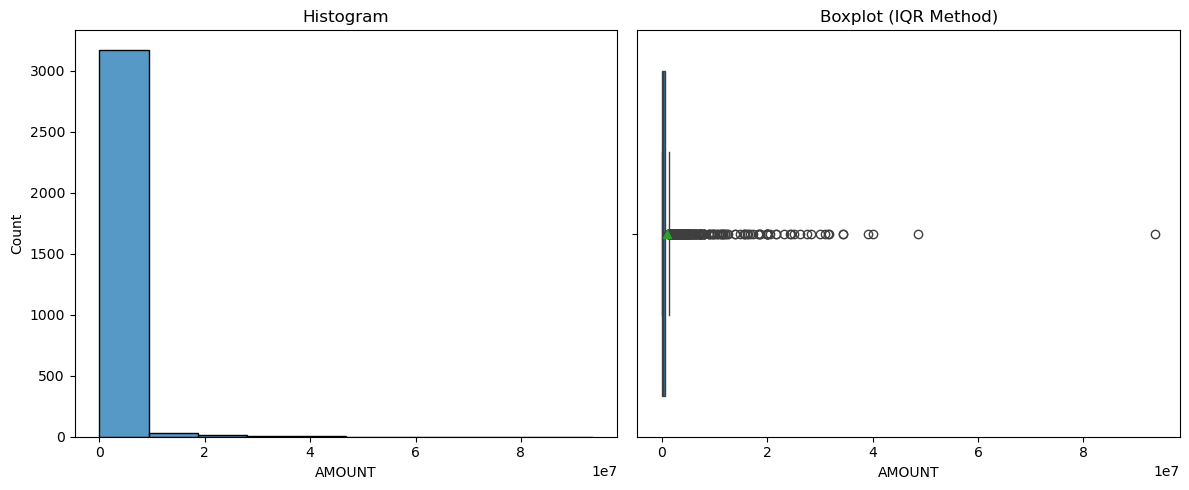

In [75]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(amount_col, bins=10, ax=axes[0])
axes[0].set_title("Histogram")

# Boxplot
sns.boxplot(data=amount_col,
            showmeans=True, orient="h", ax=axes[1])

axes[1].set_title("Boxplot (IQR Method)")

plt.tight_layout()
plt.show()

### b. Outlier Detection

In [36]:
max_row = df.loc[df["AMOUNT"].idxmax()]
print(max_row)

PAYEE                                                      UNIVERSAL STEEL SMELTING CO INC
PROJECT                                                          KINGSQUARE RESI SUITES T2
CHECK NO                                                                            113312
AMOUNT                                                                          93656250.0
APV NO                                                                          1900655311
CV NO                                                                           1500850649
PO NO                                                                           4100125958
COMPANY                                                              MEGAWORLD CORPORATION
DATE OF INCLUSION IN THE LIST OF FOR RELEASE                                     1/30/2026
RELEASING VENUE                                 ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)
BILLING NO.                                                                            PDC

Outlier %: 13.87
Non-Outlier %: 86.13


C:\Users\kenne\AppData\Local\Temp\ipykernel_13084\392218135.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="status", y="amount", data=df,


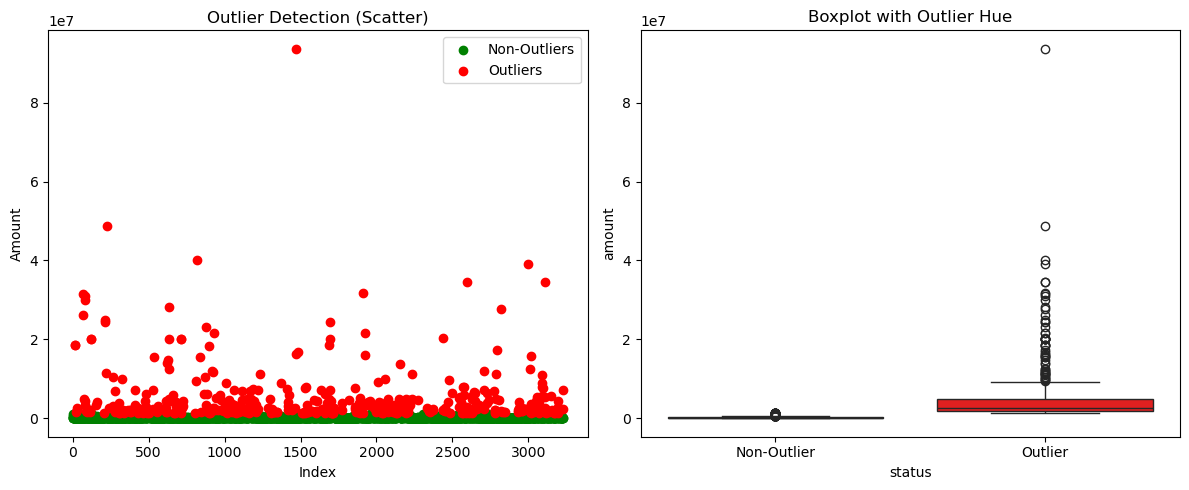

In [67]:
# IQR calculation
Q1 = amount_col.quantile(0.25)
Q3 = amount_col.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Label each value
labels = ["Outlier" if (x < lower_bound or x > upper_bound) else "Non-Outlier" for x in amount_col]
df = pd.DataFrame({"amount": amount_col, "status": labels})

# Boolean mask
outlier_mask = (amount_col < lower_bound) | (amount_col > upper_bound)

# Counts
outlier_count = outlier_mask.sum()
non_outlier_count = (~outlier_mask).sum()

total = len(amount_col)

print("Outlier %:", round((outlier_count / total) * 100, 2))
print("Non-Outlier %:", round((non_outlier_count / total) * 100, 2))

# --- Visualization ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot with colors
axes[0].scatter(non_outliers.index, non_outliers, color="green", label="Non-Outliers") 
axes[0].scatter(outliers_iqr.index, outliers_iqr, color="red", label="Outliers") 
axes[0].set_xlabel("Index") 
axes[0].set_ylabel("Amount") 
axes[0].set_title("Outlier Detection (Scatter)") 
axes[0].legend()

# Boxplot with hue
sns.boxplot(x="status", y="amount", data=df,
            palette={"Non-Outlier":"green","Outlier":"red"}, ax=axes[1])
axes[1].set_title("Boxplot with Outlier Hue")

plt.tight_layout()
plt.show()

### c. Bootstrapping

Original Mean: 894903.36
Bootstrap Mean: 895230.3
95% CI: 785709.2 to 1014650.59
Bootstrap Bias: 326.9404


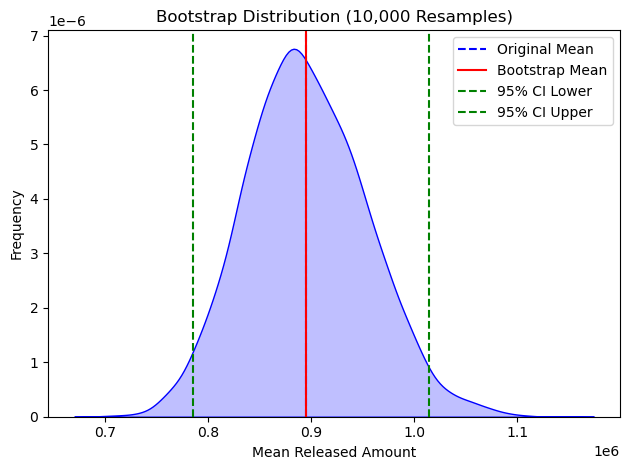

In [135]:
original_mean = amount_col.mean()
data = amount_col.dropna().values

n_bootstrap = 10000
bootstrap_means = []

for _ in range(n_bootstrap):
    sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_means.append(np.mean(sample))

bootstrap_means = np.array(bootstrap_means)

# 95% Confidence Interval
lower = round(np.percentile(bootstrap_means, 2.5), 2)
upper = round(np.percentile(bootstrap_means, 97.5), 2)

# Printing original vs bootstrap mean
print("Original Mean:", round(original_mean, 2))
print("Bootstrap Mean:", round(bootstrap_means.mean(), 2))
print("95% CI:", lower, "to", upper)

bias = bootstrap_means.mean() - original_mean
print("Bootstrap Bias:", round(bias, 4))

# Plot
plt.figure()
sns.kdeplot(bootstrap_means, color="blue", fill=True)

# Original mean line
plt.axvline(original_mean, linestyle="--", color="blue", label="Original Mean")
plt.axvline(bootstrap_means.mean(), color="red", label="Bootstrap Mean")

# Confidence interval lines
plt.axvline(lower, linestyle="--", color="green", label="95% CI Lower")
plt.axvline(upper, linestyle="--", color="green", label="95% CI Upper")

plt.title("Bootstrap Distribution (10,000 Resamples)")
plt.xlabel("Mean Released Amount")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Original Median: 124151.52
Bootstrap Median: 124776.08
95% CI: 113795.0 to 134656.82
Bootstrap Bias: 624.5557


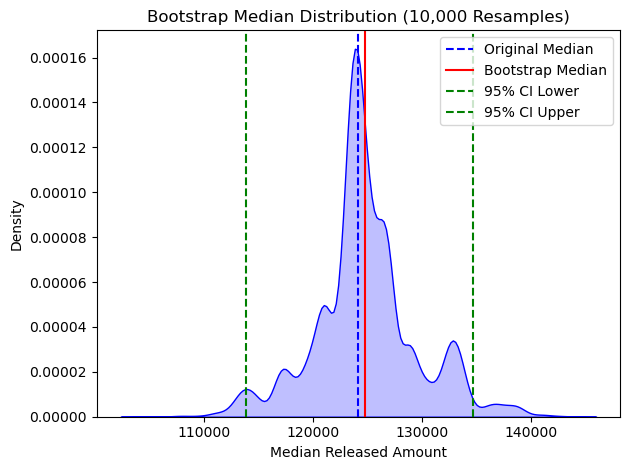

In [136]:
original_median = amount_col.median()
data = amount_col.dropna().values

n_bootstrap = 10000
bootstrap_medians = []

for _ in range(n_bootstrap):
    sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_medians.append(np.median(sample))

bootstrap_medians = np.array(bootstrap_medians)

# 95% Confidence Interval
lower = round(np.percentile(bootstrap_medians, 2.5), 2)
upper = round(np.percentile(bootstrap_medians, 97.5), 2)

# Printing original vs bootstrap median
print("Original Median:", round(original_median, 2))
print("Bootstrap Median:", round(bootstrap_medians.mean(), 2))  # mean of bootstrap medians
print("95% CI:", lower, "to", upper)

bias = bootstrap_medians.mean() - original_median
print("Bootstrap Bias:", round(bias, 4))

# Plot
plt.figure()
sns.kdeplot(bootstrap_medians, color="blue", fill=True)

# Original median line
plt.axvline(original_median, linestyle="--", color="blue", label="Original Median")
plt.axvline(bootstrap_medians.mean(), color="red", label="Bootstrap Median")

# Confidence interval lines
plt.axvline(lower, linestyle="--", color="green", label="95% CI Lower")
plt.axvline(upper, linestyle="--", color="green", label="95% CI Upper")

plt.title("Bootstrap Median Distribution (10,000 Resamples)")
plt.xlabel("Median Released Amount")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### d. Probability Distribution

                                                        params        loglik  \
Normal                   (894903.3580024774, 3383208.76503713) -53127.620742   
Binomial                                                   NaN           NaN   
Geometric                                                  NaN           NaN   
Log-Normal   (2.314058855085619, 2.077955030033255, 100301.... -44475.838265   
Gamma        (0.07547473762729039, 93656249.99999997, 7.014...          -inf   
Exponential                         (24.06, 894879.2980024774) -47480.650082   
Weibull      (0.48849208392422183, 24.059999999999995, 4324... -44583.571097   
Pareto       (0.6097675579807152, -43809.07194924974, 43833... -44633.794952   

                       AIC           BIC  \
Normal       106259.241484  106271.40134   
Binomial               NaN           NaN   
Geometric              NaN           NaN   
Log-Normal    88957.676529  88975.916313   
Gamma                  inf           inf   
Exponential   9

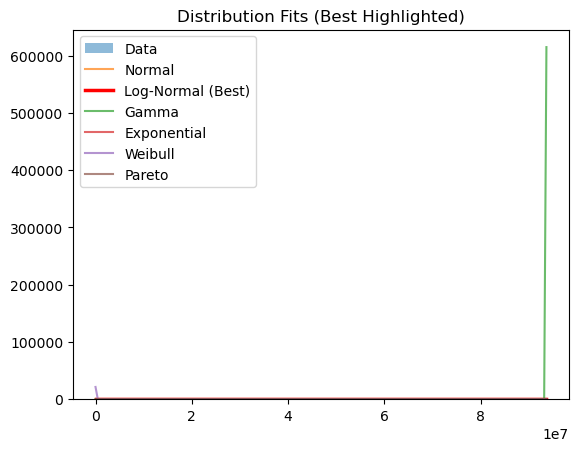

In [74]:
data = amount_col

# Candidate distributions
distributions = {
    "Normal": stats.norm,
    "Binomial": stats.binom,       # needs n, p
    "Geometric": stats.geom,       # needs p
    "Log-Normal": stats.lognorm,
    "Gamma": stats.gamma,
    "Exponential": stats.expon,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto
}

results = {}

for name, dist in distributions.items():
    try:
        # Fit distribution to data
        params = dist.fit(data)
        
        # Compute log-likelihood
        loglik = np.sum(dist.logpdf(data, *params))
        
        # AIC and BIC
        k = len(params)
        n = len(data)
        aic = 2*k - 2*loglik
        bic = k*np.log(n) - 2*loglik
        
        results[name] = {
            "params": params,
            "loglik": loglik,
            "AIC": aic,
            "BIC": bic
        }
    except Exception as e:
        results[name] = {"error": str(e)}

# Convert to DataFrame for comparison
results_df = pd.DataFrame(results).T
print(results_df)

# Rank distributions by AIC
best_aic = results_df["AIC"].idxmin()
best_bic = results_df["BIC"].idxmin()

print("-"*125)
print(f"Best fit by AIC: {best_aic}")
print(f"Best fit by BIC: {best_bic}")

# Plot histogram + PDFs
x = np.linspace(min(data), max(data), 200)
plt.hist(data, bins=30, density=True, alpha=0.5, label="Data")

for name, dist in distributions.items():
    if "params" in results[name]:
        pdf = dist.pdf(x, *results[name]["params"])
        if name == best_aic or name == best_bic:
            plt.plot(x, pdf, linewidth=2.5, label=f"{name} (Best)", color="red")
        else:
            plt.plot(x, pdf, label=name, alpha=0.7)

plt.legend()
plt.title("Distribution Fits (Best Highlighted)")
plt.show()

# The lower AIC/BIC fit, the better

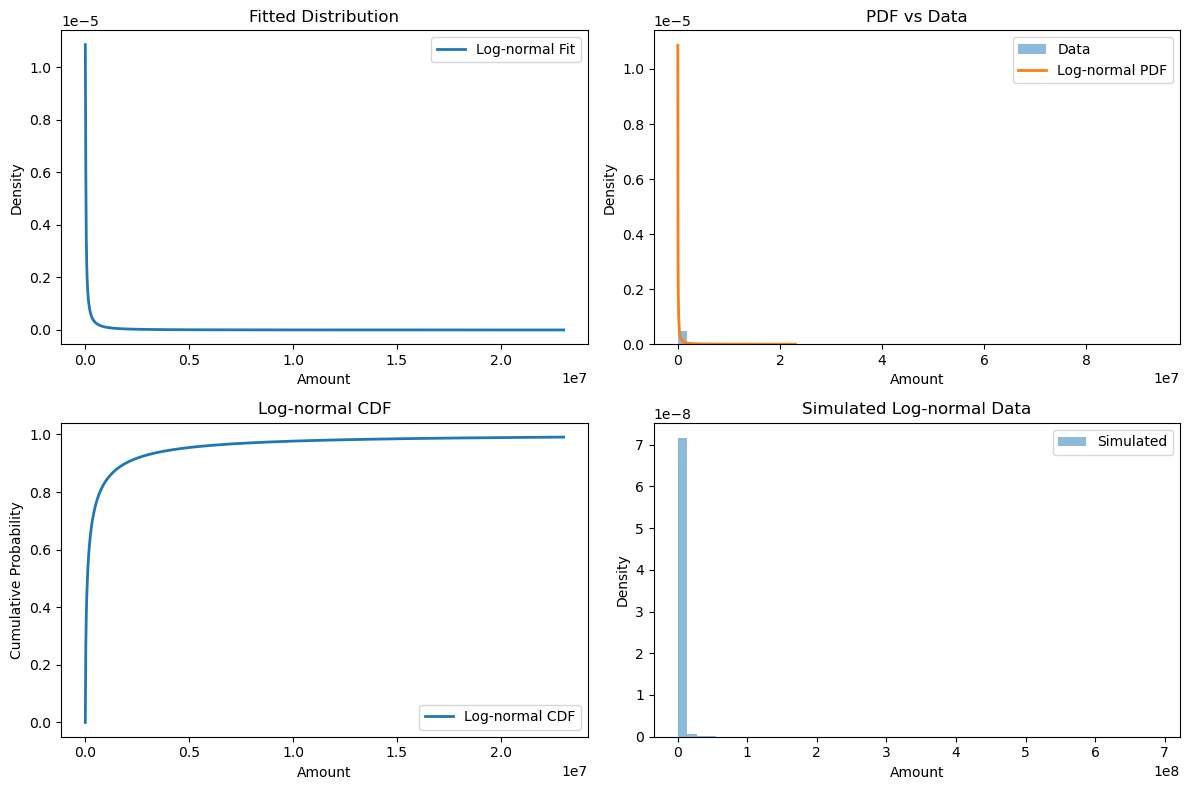

In [25]:
# Fit log-normal distribution
shape, loc, scale = lognorm.fit(data, floc=0)

# Prepare x values
fitted_dataset = np.linspace(min(data), np.percentile(data, 99.5), 1000)
pdf_vals = lognorm.pdf(fitted_dataset, shape, loc, scale)
cdf_vals = lognorm.cdf(fitted_dataset, shape, loc, scale)

# Simulated data
simulated = lognorm.rvs(shape, loc, scale, size=10000)

plt.figure(figsize=(12, 8))

# -- Histogram of Fitted Dataset --
plt.subplot(2, 2, 1)
plt.plot(fitted_dataset, pdf_vals, lw=2, label='Log-normal Fit')
plt.title("Fitted Distribution")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

# --- PDF ---
plt.subplot(2, 2, 2)
plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
plt.plot(fitted_dataset, pdf_vals, lw=2, label='Log-normal PDF')
plt.title("PDF vs Data")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

# --- CDF ---
plt.subplot(2, 2, 3)
plt.plot(fitted_dataset, cdf_vals, lw=2, label='Log-normal CDF')
plt.title("Log-normal CDF")
plt.xlabel("Amount")
plt.ylabel("Cumulative Probability")
plt.legend()

# --- Simulation ---
plt.subplot(2, 2, 4)
plt.hist(simulated, bins=50, density=True, alpha=0.5, label='Simulated')
plt.title("Simulated Log-normal Data")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# We can now use Statistics in fitted dataset but before that, let's answer the number 1 problem first.

### Exploratory Data Analysis On Concern no. 1

## 2. What is the probability that a randomly selected release amount falls between ₱50,000 and ₱1,000,000?

In [28]:
# Fitting the very skewed dataset
shape, loc, scale = lognorm.fit(data, floc=0)

lower = 50000
upper = 1000000

# Compute probability
probability = lognorm.cdf(upper, shape, loc, scale) - \
              lognorm.cdf(lower, shape, loc, scale)

print("Probability between 50,000 and 1,000,000:", probability)
print(f"Percentage: {probability * 100:.2f}%")

Probability between 50,000 and 1,000,000: 0.45819307683202676
Percentage: 45.82%


## 3. What is the probability that a randomly selected transaction exceeds ₱1,000,000?

In [40]:
threshold = 1000000

probability = 1 - lognorm.cdf(threshold, shape, loc, scale)

print("Probability amount exceeds 2,000,000:", probability)
print(f"Percentage: {probability * 100:.2f}%")

Probability amount exceeds 2,000,000: 0.1601294966577037
Percentage: 16.01%


## 4. WHY DOES RELEASING VENUE IS ALWAYS AGT

In [41]:
df["RELEASING VENUE"].value_counts()

RELEASING VENUE
ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)                                                                  1776
UBP MCKINLEY WEST – LAWTON AVENUE LOWER G/F, ROBINSONS CYBER SIGMA BUILDING, BONIFACIO SOUTH TAGUIG CITY    1386
ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-4pm)                                                                    30
UBP CPS CEBU L/G Aboitiz Corporate Center Gov. Manuel A. Cuenco Ave., Kasambagan, Cebu City 6000              27
BDO - ILOILO                                                                                                   8
BDO ILOILO                                                                                                     2
Name: count, dtype: int64

In [40]:
# This minor data cleaning was already done in PowerBI
df["RELEASING VENUE"] = df["RELEASING VENUE"].replace(
    "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-4pm)",
    "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)"
)

df["RELEASING VENUE"] = df["RELEASING VENUE"].replace(
    "BDO - ILOILO",
    "BDO ILOILO"
)

df["RELEASING VENUE"].value_counts()

# Here, ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-4pm) is now converted to ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm) 

RELEASING VENUE
ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)                                                                  1806
UBP MCKINLEY WEST – LAWTON AVENUE LOWER G/F, ROBINSONS CYBER SIGMA BUILDING, BONIFACIO SOUTH TAGUIG CITY    1386
UBP CPS CEBU L/G Aboitiz Corporate Center Gov. Manuel A. Cuenco Ave., Kasambagan, Cebu City 6000              27
BDO ILOILO                                                                                                    10
Name: count, dtype: int64

C:\Users\kenne\AppData\Local\Temp\ipykernel_16572\800426523.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=venue_counts, x="count", y=releasing_venue, palette="viridis")


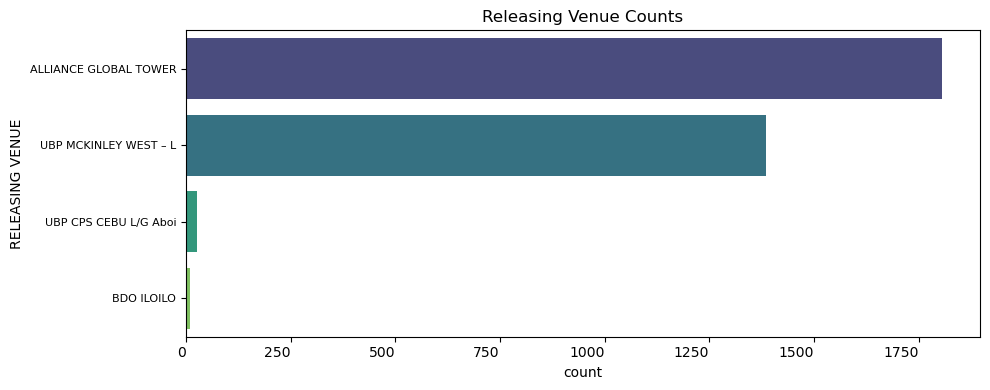

In [41]:
venue_counts = df["RELEASING VENUE"].value_counts().reset_index()
venue_counts.columns = ["RELEASING VENUE", "count"]
releasing_venue = venue_counts["RELEASING VENUE"].str.slice(0, 21)

plt.figure(figsize=(10,4))
sns.barplot(data=venue_counts, x="count", y=releasing_venue, palette="viridis")

plt.xticks(ha="right", fontsize=10)
plt.yticks(fontsize=8)
plt.title("Releasing Venue Counts")
plt.tight_layout()
plt.show()

In [ ]:
Considering the top two release Alliance Global Tower vs UBP Mckinley West

In [59]:
agt_amount_released = df[df["RELEASING VENUE"] == 
    "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)"]

ubp_amount_released = df[df["RELEASING VENUE"] == 
    "UBP MCKINLEY WEST – LAWTON AVENUE LOWER G/F, ROBINSONS CYBER SIGMA BUILDING, BONIFACIO SOUTH TAGUIG CITY"]

print(agt_amount_released.info())
print("*"*125)
print(ubp_amount_released.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1776 entries, 0 to 3228
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   PAYEE                                         1776 non-null   object 
 1   PROJECT                                       1776 non-null   object 
 2   CHECK NO                                      1776 non-null   object 
 3   AMOUNT                                        1776 non-null   float64
 4   APV NO                                        1776 non-null   object 
 5   CV NO                                         1776 non-null   object 
 6   PO NO                                         1771 non-null   object 
 7   COMPANY                                       1776 non-null   object 
 8   DATE OF INCLUSION IN THE LIST OF FOR RELEASE  1776 non-null   object 
 9   RELEASING VENUE                               1776 non-null   object

C:\Users\kenne\AppData\Local\Temp\ipykernel_31960\3841216028.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


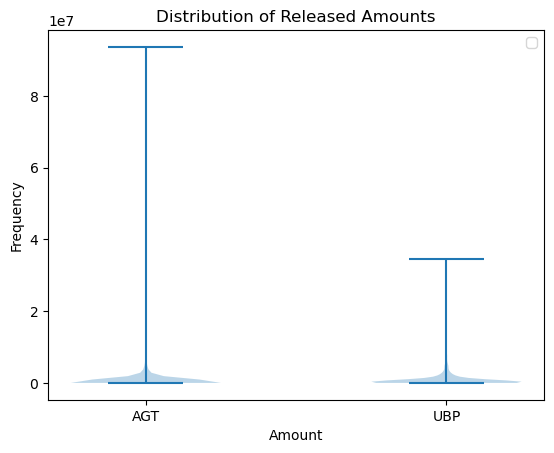

In [68]:
agt_amount_subset = agt_amount_released["AMOUNT"]
ubp_amount_subset = ubp_amount_released["AMOUNT"]

# Plot histograms
plt.violinplot([agt_amount_subset, ubp_amount_subset])
plt.xticks([1, 2], ['AGT', 'UBP'])

# Add labels and legend
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Released Amounts")
plt.legend()

plt.show()

In [ ]:
# Recall, our dataset is greatly skewed to the right. Hence, we'll use non-parametric 

In [62]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U Test
stat, p_value = mannwhitneyu(agt_amount_subset, ubp_amount_subset, alternative='two-sided')
    
# Determine significance description
if p_value <= 0.005:
    significance_result = "The difference is highly statistically significant between AGT & UBP"
elif p_value <= 0.05:
    significance_result = "The difference is statistically significant between AGT & UBP"
else:
    significance_result = "There is no statistical significance between the difference AGT & UBP"

print("U Statistic:", stat)
print("P-value:", p_value)
print(significance_result)

U Statistic: 768921.0
P-value: 1.7950119894248176e-73
The difference is highly statistically significant between AGT & UBP


In [42]:
# Chisquare Test does not need normality and not affected much by outliers. It assumes frequency table, not continuous measurement.

from scipy.stats import chisquare

counts = df["RELEASING VENUE"].value_counts()

observed = counts.values
expected = [sum(observed)/len(observed)] * len(observed)

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Observed:", observed)
print("Expected:", expected)
print("Chi-square:", chi_stat)
print("P-value:", p_value)

# P-Value is p<=0.05, 

Observed: [1806 1386   27   10]
Expected: [np.float64(807.25), np.float64(807.25), np.float64(807.25), np.float64(807.25)]
Chi-square: 3192.134716630536
P-value: 0.0


## 5. TIME SERIES FORECASTING

## 6. GENERATING MACHINE LEARNING MODELS

In [ ]:
###############################################################################################################################